# Загрузка датасета

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import math
import scipy.stats as stats
from ucimlrepo import fetch_ucirepo
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns


statlog_heart = fetch_ucirepo(id=145)

df = statlog_heart.data.features.copy()
df['target'] = statlog_heart.data.targets

# Преобразование к бинарной классификации
y = df['target'].map({1: 0, 2: 1})
df['target'] = y

display(df.head())

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,target
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,1
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,0
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,1
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,0
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,0


# Дескриптивный анализ

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,"Квантили (25%, 50%, 75%)",Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,age - Возраст,54.43,55.0,54.0,29.0,77.0,9.11,82.98,-0.16,-0.54,"{0.25: 48.0, 0.5: 55.0, 0.75: 61.0}",p=1.755e-01 → Нормальное
1,"sex - Пол (0 - женский, 1 - мужской)",0.68,1.0,1.0,0.0,1.0,0.47,0.22,-0.77,-1.43,"{0.25: 0.0, 0.5: 1.0, 0.75: 1.0}",p=2.463e-46 → Далеко от нормального
2,chest-pain - Тип боли в груди,3.17,3.0,4.0,1.0,4.0,0.95,0.90,-0.88,-0.30,"{0.25: 3.0, 0.5: 3.0, 0.75: 4.0}",p=5.797e-20 → Далеко от нормального
3,rest-bp - Артериальное давление в покое,131.34,130.0,120.0,94.0,200.0,17.86,319.04,0.72,0.92,"{0.25: 120.0, 0.5: 130.0, 0.75: 140.0}",p=8.052e-03 → Далеко от нормального
4,serum-chol - Уровень холестерина в сыворотки к...,249.66,245.0,234.0,126.0,564.0,51.69,2671.47,1.18,4.90,"{0.25: 213.0, 0.5: 245.0, 0.75: 280.0}",p=4.696e-01 → Нормальное
5,fasting-blood-sugar - Уровень сахара в крови,0.15,0.0,0.0,0.0,1.0,0.36,0.13,1.99,1.98,"{0.25: 0.0, 0.5: 0.0, 0.75: 0.0}",p=1.514e-66 → Далеко от нормального
6,electrocardiographic - Результаты ЭКГ в покое,1.02,2.0,2.0,0.0,2.0,1.00,1.00,-0.04,-2.01,"{0.25: 0.0, 0.5: 2.0, 0.75: 2.0}",p=5.247e-29 → Далеко от нормального
7,max-heart-rate - Максимальный пульс,149.68,153.5,162.0,71.0,202.0,23.17,536.65,-0.53,-0.10,"{0.25: 133.0, 0.5: 153.5, 0.75: 166.0}",p=7.147e-02 → Нормальное
8,angina - Стенокардия вызванная физической нагр...,0.33,0.0,0.0,0.0,1.0,0.47,0.22,0.73,-1.48,"{0.25: 0.0, 0.5: 0.0, 0.75: 1.0}",p=1.658e-45 → Далеко от нормального
9,oldpeak - Дисперсия сегмента ST,1.05,0.8,0.0,0.0,6.2,1.15,1.31,1.26,1.76,"{0.25: 0.0, 0.5: 0.8, 0.75: 1.6}",p=4.309e-08 → Далеко от нормального


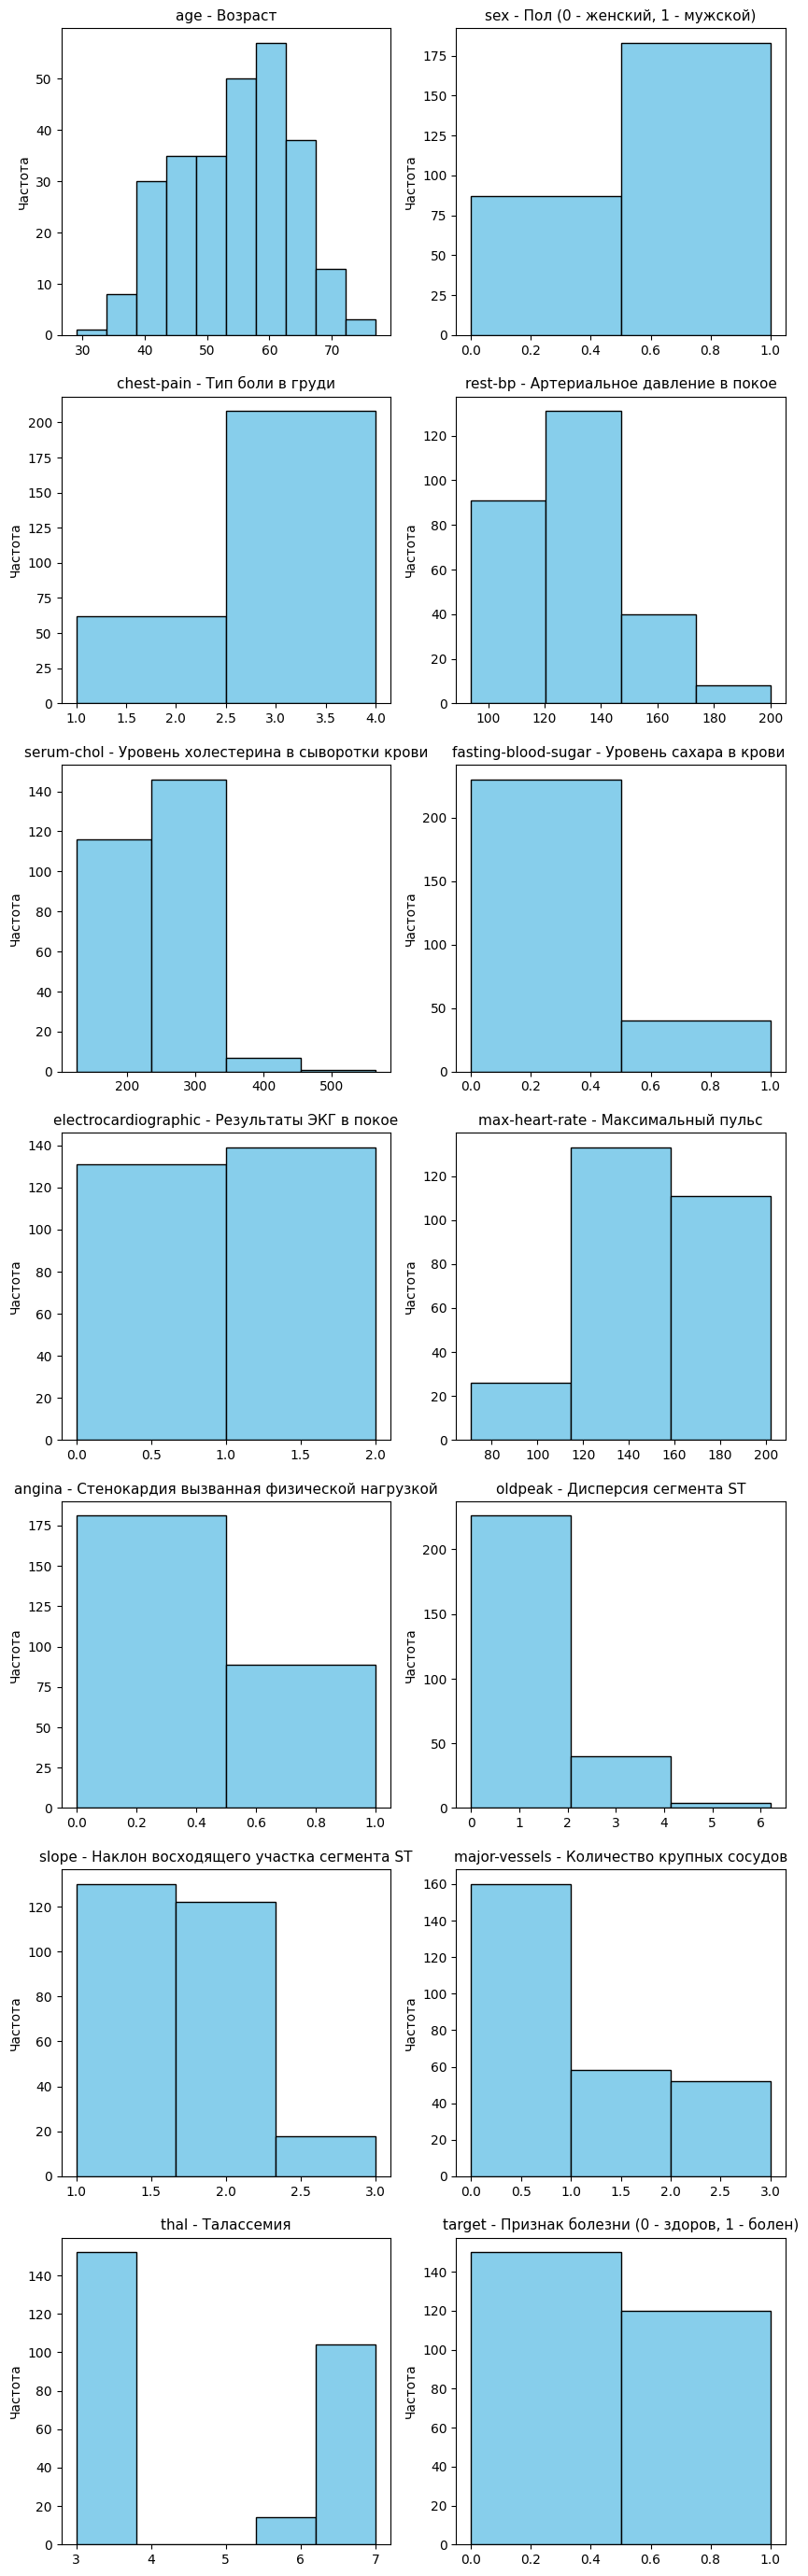

In [15]:
n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
        
translate = {
    "age" : "age - Возраст",
    "sex": "sex - Пол (0 - женский, 1 - мужской)",
    "chest-pain": "chest-pain - Тип боли в груди",
    "rest-bp" : "rest-bp - Артериальное давление в покое",
    "serum-chol": "serum-chol - Уровень холестерина в сыворотки крови",
    "fasting-blood-sugar": "fasting-blood-sugar - Уровень сахара в крови ",
    "electrocardiographic": "electrocardiographic - Результаты ЭКГ в покое",
    "max-heart-rate": "max-heart-rate - Максимальный пульс",
    "angina": "angina - Стенокардия вызванная физической нагрузкой",
    "oldpeak": "oldpeak - Дисперсия сегмента ST",
    "slope": "slope - Наклон восходящего участка сегмента ST",
    "major-vessels": "major-vessels - Количество крупных сосудов",
    "thal": "thal - Талассемия",
    "target": "target - Признак болезни (0 - здоров, 1 - болен)"
}


features = df.columns
fig, axes = plt.subplots(7, 2, figsize=(10, 35))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [], "Квантили (25%, 50%, 75%)": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    # Собируем статистику
    stat["Признак"].append(translate[feature])
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Квантили (25%, 50%, 75%)"].append(df[feature].quantile([0.25, 0.5, 0.75]).to_dict())
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    # Строим гистограммы для всех признаков
    if (feature in ["sex", "target", "fasting-blood-sugar", "angina"]):
        k_ = 2
    elif (feature in ["electrocardiographic", "slope"]):
        k = 3
    elif (feature in ["chest-pain", "major-vessels"]):
        k = 4
    elif (feature == "thal"):
        k_ = 5
    else:
        k_ = k

    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(translate[feature], fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

Таким образом, предположение о нормальности данных не выполняется, что нужно учитывать при выборе методов классификации — линейные методы (например, линейный дискриминантный анализ) здесь будут работать хуже. 
Более подходящие — непараметрические алгоритмы: дерево решений, метод k-ближайших соседей, случайный лес, SVM и т.п.

По гистограмме видно, что классы распределены относительно сбалансировано (около 55–60 % больных и 40–45 % здоровых), что благоприятно для обучения классификаторов — дополнительная балансировка не требуется.

# Матрица корреляции

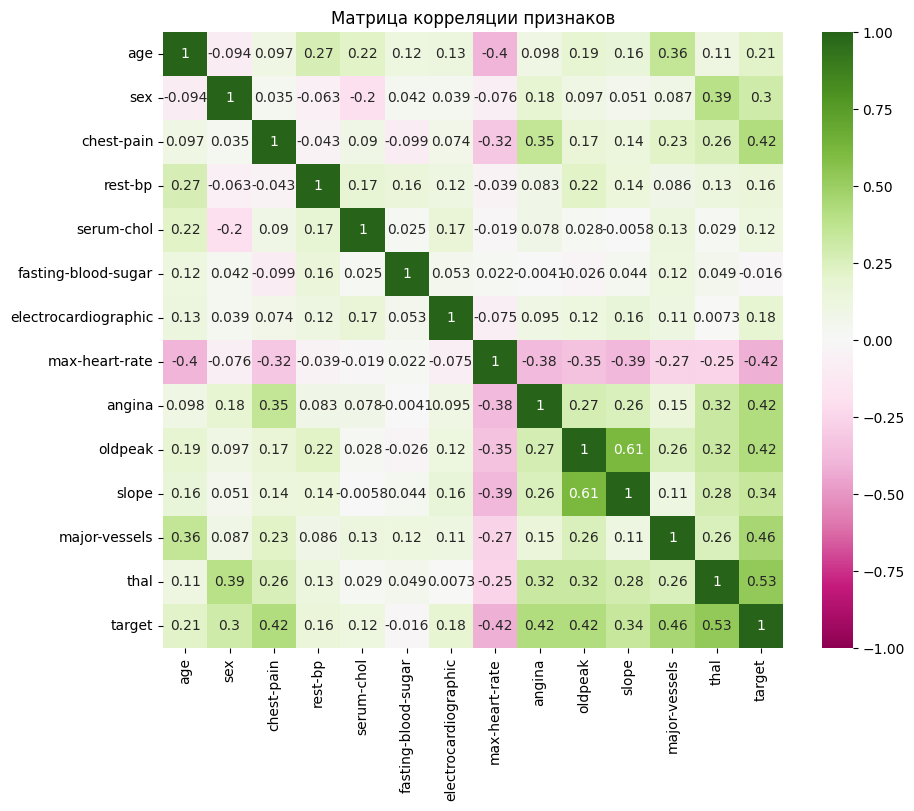

In [16]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='PiYG', vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков")
plt.show()

# Матрица корреляции после удаления

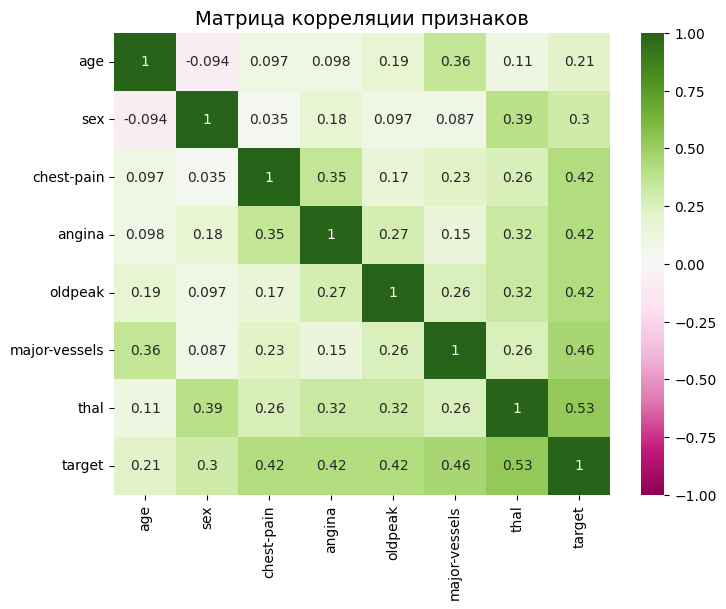

In [17]:
# Удаление сильнокорелирующих и слабоколерующих (с target) признаков
df = df.drop(columns=["slope"])
df = df.drop(columns=["max-heart-rate"])
df = df.drop(columns=["rest-bp"])
df = df.drop(columns=["serum-chol"])
df = df.drop(columns=["fasting-blood-sugar"])
df = df.drop(columns=["electrocardiographic"])

# Заново строим
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sb.heatmap(corr_matrix, annot=True, cmap='PiYG', vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков", fontsize=14)
plt.show()

# Категоризованная диаграмма рассеивания

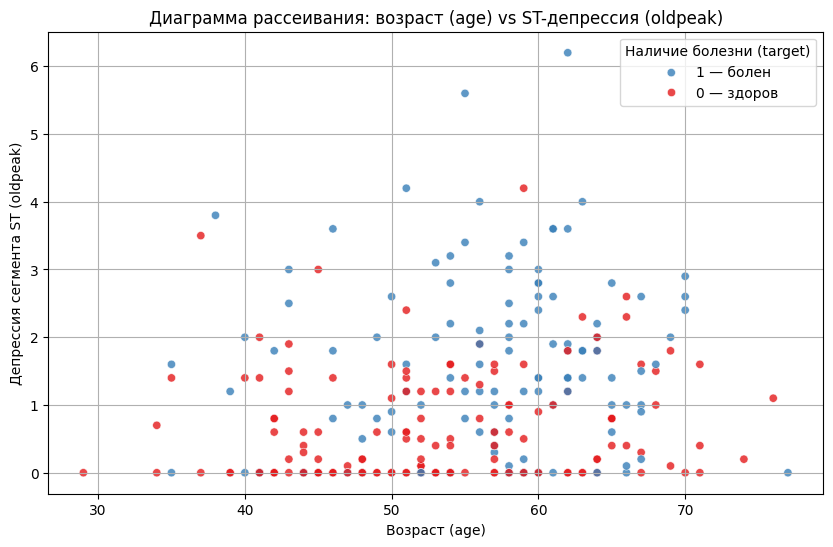

In [18]:
# Диаграмма рассеивания
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='age',
    y='oldpeak',
    hue='target',
    palette='Set1',
    alpha=0.8
)

plt.title('Диаграмма рассеивания: возраст (age) vs ST-депрессия (oldpeak)')
plt.xlabel('Возраст (age)')
plt.ylabel('Депрессия сегмента ST (oldpeak)')
plt.legend(title='Наличие болезни (target)', labels=['1 — болен', '0 — здоров'])
plt.grid(True)
plt.show()


# Подготовка данных

In [19]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

def print_metrics(y_true, y_pred, y_score, class_names):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    report = classification_report(
        y_true, y_pred, target_names=class_names,
        output_dict=True, zero_division=0
    )
    df = pd.DataFrame(report).T.rename(
        columns={'precision': 'precision', 'recall': 'recall', 'f1-score': 'f1-score'}
    ).round(2)

    y_score = np.asarray(y_score)
    if y_score.ndim == 2 and y_score.shape[1] >= 2:
        y_score = y_score[:, 1]
    auc_value = roc_auc_score(y_true, y_score)
    df.loc[class_names[1], 'ROC-AUC'] = round(auc_value, 3)

    acc = accuracy_score(y_true, y_pred)
    df.loc['accuracy', ['precision','recall']] = np.nan
    df.loc['accuracy', ['f1-score']] = round(acc, 2)
    df.loc['accuracy', ['support']] = len(y_true)

    order = class_names + ['accuracy', 'macro avg', 'weighted avg']
    df = df.reindex(order).fillna("")

    display(df)

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', values_format='d')
    plt.gca().grid(False)
    plt.title('Confusion Matrix')
    plt.show()

    if y_score is not None:
        RocCurveDisplay.from_predictions(y_true, y_score)
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('ROC-кривая')
        plt.legend()
        plt.show()
    
    return df





X = df.drop('target', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Разделение на обучающую и тестовую выборки

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Дерево решений

## Поиск лучшей глубины дерева

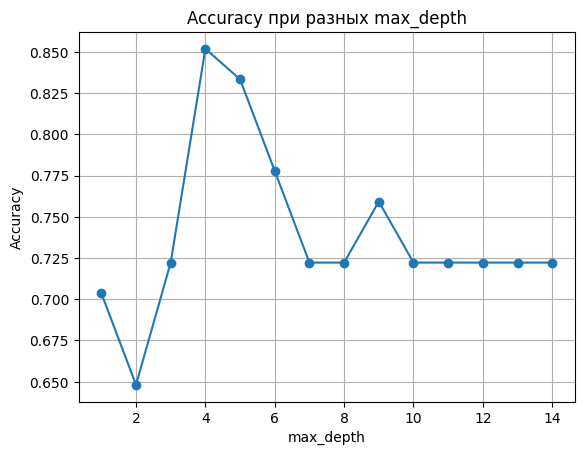

Лучший результат: depth = 4, Accuracy = 0.852


In [20]:
from sklearn.tree import DecisionTreeClassifier

depths = range(1, 15)
acc = []

for d in depths:
    clf = DecisionTreeClassifier(random_state=42, max_depth=d)
    clf.fit(X_train, y_train)
    acc.append(accuracy_score(y_test, clf.predict(X_test)))

plt.plot(depths, acc, marker='o')
plt.title('Accuracy при разных max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

print(f"Лучший результат: depth = {depths[acc.index(max(acc))]}, Accuracy = {max(acc):.3f}")

## Создание дерева решений

,precision,recall,f1-score,support,ROC-AUC
Здоров - 0,0.88,0.88,0.88,33.0,
Болен - 1,0.81,0.81,0.81,21.0,0.86
accuracy,,,0.85,54.0,
macro avg,0.84,0.84,0.84,54.0,
weighted avg,0.85,0.85,0.85,54.0,


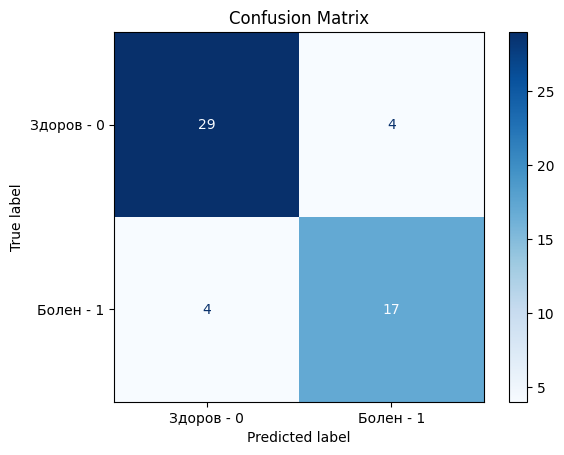

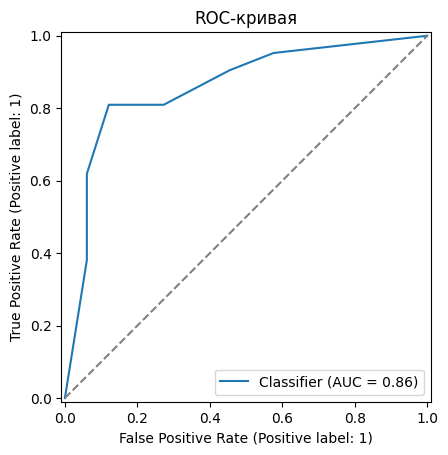

In [21]:
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

tree_result = print_metrics(y_test, y_pred, y_prob, class_names=["Здоров - 0", "Болен - 1"])

## Визуализиця дерева решения

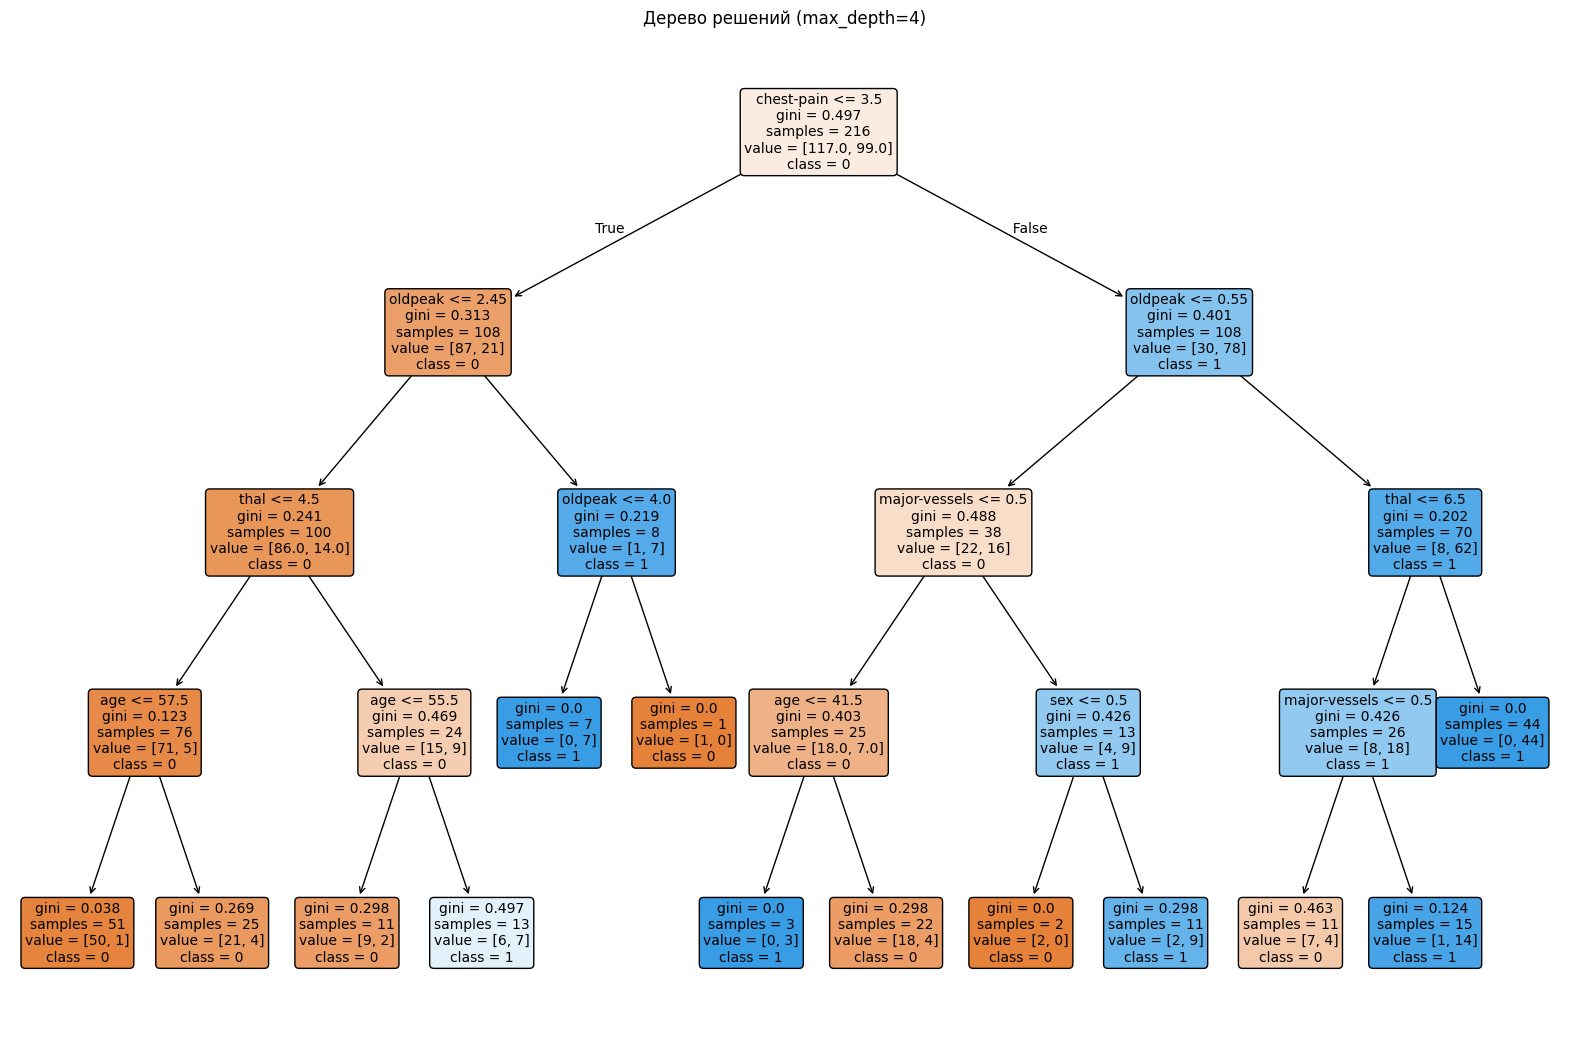

In [22]:
from sklearn.tree import plot_tree

feature_names = [col for col in df.columns if col != 'target']

plt.figure(figsize=(20, 13))
plot_tree(clf, 
          feature_names=feature_names,
          class_names=[str(x) for x in clf.classes_],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений (max_depth=4)")
plt.show()

# Метод ближайших соседей

# Подбор лучшего k

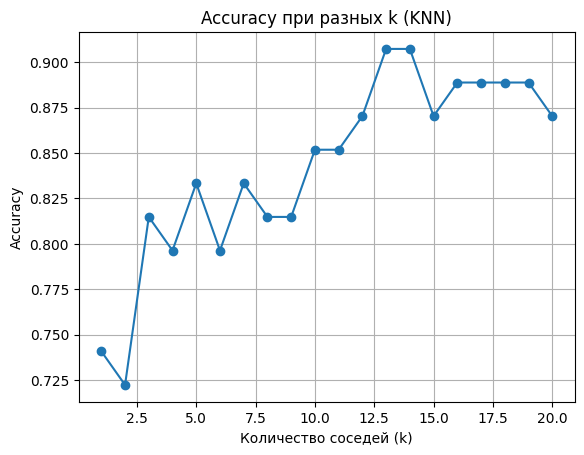

Лучшее значение k = 13, Accuracy = 0.907


In [23]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 21)
acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, acc, marker='o')
plt.title('Accuracy при разных k (KNN)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

best_k = k_values[acc.index(max(acc))]
print(f"Лучшее значение k = {best_k}, Accuracy = {max(acc):.3f}")

# Решение методом ближайших соседей

,precision,recall,f1-score,support,ROC-AUC
Здоров - 0,0.87,1.0,0.93,33.0,
Болен - 1,1.0,0.76,0.86,21.0,0.905
accuracy,,,0.91,54.0,
macro avg,0.93,0.88,0.90,54.0,
weighted avg,0.92,0.91,0.90,54.0,


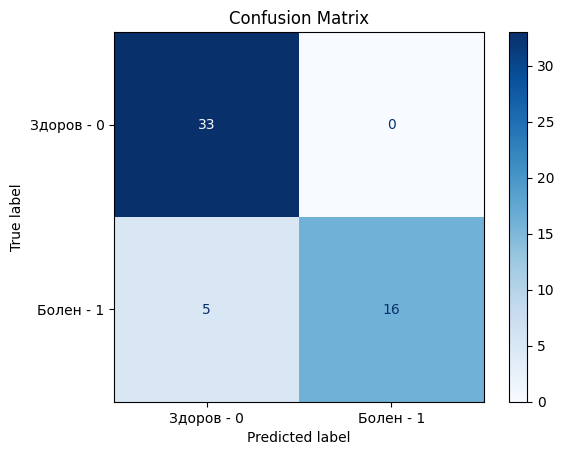

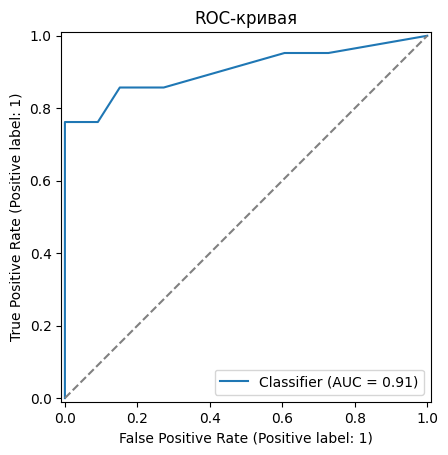

In [24]:
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

knn_result = print_metrics(y_test, y_pred, y_prob, class_names=["Здоров - 0", "Болен - 1"])

# Выводы (нагенерила!! - перепиши)

## Дерево решений
- Модель дерева решений показывает сбалансированную точность по обоим классам — как «здоровые», так и «больные» определяются примерно с одинаковым качеством.
- ROC-AUC = 0.86 говорит о достаточной способности модели отделять классы (хорошая, но не идеальная разделимость).
- Показатели precision и recall для больных (1) немного ниже, что может означать, что модель некоторых больных относит к здоровым (ложноотрицательные).
- При этом дерево даёт хорошую интерпретируемость — можно визуализировать логику принятия решения и оценить важность признаков.
- Модель дерева решений демонстрирует стабильные результаты, хорошо подходит для интерпретации и анализа важности признаков, но немного уступает по общей точности.

## Соседи
- Модель KNN показывает более высокую точность (91%) и лучшую разделимость классов по метрике ROC-AUC = 0.905.
- У модели наблюдается перекос по классам:
    - она очень точно распознаёт здоровых (recall = 1.00),
    - но пропускает часть больных (recall = 0.76) — то есть делает больше ложных отрицаний.
    - Высокие значения precision (особенно 1.0 для больных) говорят, что если модель сказала «болен» — почти всегда это верно, но она не всегда обнаруживает всех больных.
    - KNN даёт лучшую общую точность и качество разделения классов, но немного хуже работает с больными пациентами по полноте (recall). Это типично для алгоритма, чувствительного к распределению данных и масштабам признаков.

## Сравнительный анализ
| Метрика            | Decision Tree | KNN (k=13) | Лучшая     |
| ------------------ | ------------- | ---------- | ---------  |
| Accuracy           | 0.85          | **0.91**   | 🟢 KNN    |
| ROC-AUC            | 0.86          | **0.91**   | 🟢 KNN    |
| F1 (macro avg)     | 0.84          | **0.90**   | 🟢 KNN    |
| Recall (больные)   | **0.81**      | 0.76       | 🟡 Дерево |
| Интерпретируемость | 🟢 Высокая    | 🔴 Низкая | —          |


KNN превосходит дерево решений по основным метрикам точности и ROC-AUC, обеспечивая более общее качество классификации.
- Дерево решений лучше балансирует классы и даёт более интерпретируемые результаты.
- Для практического применения:
    - если важна максимальная точность предсказаний — использовать KNN;
    - если важна понятность логики и объяснимость модели — использовать дерево решений.

(от меня) - если смотреть не только на циферки а на контекст датасета, то дерево лучше, т.к. лучше определяет больных. Уж лучше сказать что здоровый - больной, чем больной - здоровый


## Анализ ROC-кривой
| Вид ROC-кривой                       | Что означает                                                                          |
| ------------------------------------ | ------------------------------------------------------------------------------------- |
| 🟢 **Близко к левому верхнему углу** | Отличное разделение классов — высокая чувствительность и низкий уровень ложных тревог |
| 🟡 **Близко к диагонали (x=y)**      | Модель угадывает почти случайно                                                       |
| 🔴 **Ниже диагонали**                | Модель ошибается чаще, чем угадывает (антипредсказатель)                              |


и объяснение что это такое

Представь, что твоя модель (например, KNN) не просто говорит “болен / здоров”,
а оценивает вероятность того, что человек болен — например:

| Пациент | Вероятность болезни |
| ------- | ------------------- |
| 1       | 0.95                |
| 2       | 0.80                |
| 3       | 0.45                |
| 4       | 0.20                |
| 5       | 0.05                |

Теперь тебе нужно решить, где провести границу (порог):
при какой вероятности считать человека больным?

🔸 Пример:

- Если выбрать порог = 0.5
→ всё, что ≥ 0.5 = “болен”, остальное “здоров”.

- Если порог сделать 0.8
→ модель станет строже — она ошибётся меньше (меньше ложных тревог),
но и пропустит больше больных.

- Если порог = 0.2
→ почти всех назовёт больными,
найдёт всех реальных больных,
но появится куча ложных тревог.

🔹 Что делает ROC-кривая

ROC-кривая показывает, как меняется поведение модели при изменении порога:

- по оси X — сколько здоровых модель ошибочно считает больными (False Positive Rate),

- по оси Y — сколько больных она правильно находит (True Positive Rate).

То есть — чем левее и выше кривая, тем лучше модель умеет отделять классы при любых порогах.

AUC — это площадь под этой кривой.
Это просто число, которое показывает, насколько “высоко” кривая находится.

| AUC     | Что значит                                    |
| ------- | --------------------------------------------- |
| 1.0     | идеальная модель — всегда правильно различает |
| 0.9–1.0 | отличная модель                               |
| 0.8–0.9 | хорошая                                       |
| 0.7–0.8 | средняя                                       |
| 0.5     | случайное угадывание                          |
| < 0.5   | хуже, чем случайность                         |




# Заигрывания с деревом

,criterion,max_depth,Accuracy,Precision,Recall,F1,AUC
7,entropy,1,0.704,0.619,0.619,0.619,0.688
8,entropy,2,0.704,0.692,0.429,0.529,0.742
9,entropy,3,0.759,0.682,0.714,0.698,0.815
10,entropy,4,0.833,0.875,0.667,0.757,0.812
11,entropy,5,0.778,0.765,0.619,0.684,0.780
12,entropy,7,0.778,0.714,0.714,0.714,0.802
13,entropy,10,0.815,0.762,0.762,0.762,0.805
0,gini,1,0.704,0.619,0.619,0.619,0.688
1,gini,2,0.648,0.562,0.429,0.486,0.670
2,gini,3,0.722,0.650,0.619,0.634,0.804


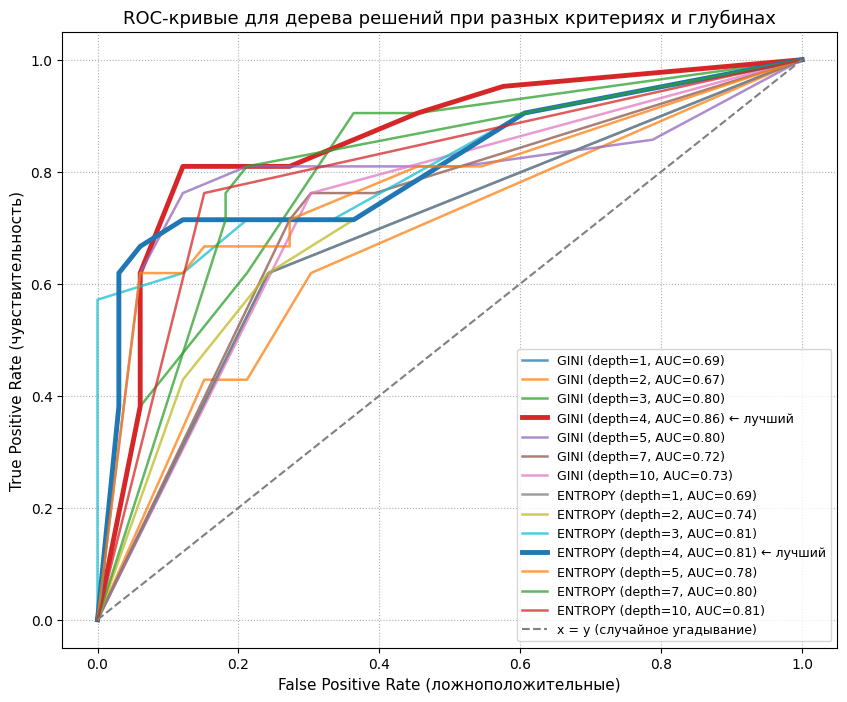

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import pandas as pd, matplotlib.pyplot as plt

depths = [1, 2, 3, 4, 5, 7, 10]
criteria = ['gini', 'entropy']
rows, rocs = [], {}

for crit in criteria:
    for d in depths:
        m = DecisionTreeClassifier(random_state=42, max_depth=d, criterion=crit).fit(X_train, y_train)
        y_pred  = m.predict(X_test)
        y_score = m.predict_proba(X_test)[:, 1]
        rows.append({
            'criterion': crit,
            'max_depth': d,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'AUC': roc_auc_score(y_test, y_score)
        })
        rocs[(crit, d)] = roc_curve(y_test, y_score)[:2]

results = pd.DataFrame(rows).round(3).sort_values(['criterion', 'max_depth'])
display(results)

best_idx = results.groupby('criterion')['Accuracy'].idxmax()
best = results.loc[best_idx].set_index('criterion')
best_depths = {c: int(best.loc[c, 'max_depth']) for c in criteria}

plt.figure(figsize=(10, 8))
for (crit, d), (fpr, tpr) in rocs.items():
    auc = results.set_index(['criterion', 'max_depth']).loc[(crit, d), 'AUC']
    lw = 1.8
    alpha = 0.75
    label = f"{crit.upper()} (depth={d}, AUC={auc:.2f})"
    if d == best_depths[crit]:
        lw, alpha = 3.5, 1.0
        label += " ← лучший"
    plt.plot(fpr, tpr, linewidth=lw, alpha=alpha, label=label)

plt.plot([0, 1], [0, 1], '--', color='gray', label='x = y (случайное угадывание)')
plt.title('ROC-кривые для дерева решений при разных критериях и глубинах', fontsize=13)
plt.xlabel('False Positive Rate (ложноположительные)', fontsize=11)
plt.ylabel('True Positive Rate (чувствительность)', fontsize=11)
plt.legend(loc='lower right', fontsize=9, frameon=True)
plt.grid(True, linestyle=':')
plt.show()


# Переделай
| Диапазон  | Характер модели                       | Поведение метрик                                                               |
| --------- | ------------------------------------- | ------------------------------------------------------------------------------ |
| **1–3**   | Недообучение (слишком простое дерево) | Accuracy < 0.75, F1 низкий; модель не улавливает закономерности.               |
| **4–5**   | Оптимальная сложность                 | Резкий рост Accuracy до **0.85**, AUC до **0.86**, хорошие Precision и Recall. |
| **6–10+** | Начало переобучения                   | Метрики постепенно падают, колеблются в районе 0.72–0.78, AUC снижается.       |
